In [ ]:
from segment_anything import SamPredictor, sam_model_registry

In [3]:
model_type = 'vit_h'
model_path = "./sam_vit_h_4b8939.pth"

In [4]:
sam = sam_model_registry[model_type](checkpoint=model_path)
sam.to("cuda")
predictor = SamPredictor(sam)

In [5]:
import numpy as np
img_rgb = np.load("./images/rgb2.npy")[:,:,:3]
predictor.set_image(img_rgb)

In [6]:
import torch
depth_img = np.load("./images/depth2.npy")
depth_img = torch.tensor(depth_img)

In [7]:
def world_to_pixel(obj_pos, view_matrix, proj_matrix, width, height):
    point_world = np.array([*obj_pos, 1.0])

    point_cam = view_matrix @ point_world
    z_cam = point_cam[2]
    point_clip = proj_matrix @ point_cam

    point_ndc = point_clip[:3] / point_clip[3]
    if not (-1 <= point_ndc[0] <= 1 and -1 <= point_ndc[1] <= 1):
        print("该点在视野范围外")
        return None, None, z_cam

    u = (point_ndc[0] + 1) * 0.5 * width
    v = (1 - point_ndc[1]) * 0.5 * height

    return u, v, z_cam


In [8]:
obj_pos = np.load("./images/object_pose2.npy")[:,:3].reshape(-1)

In [9]:
height, width = depth_img.shape  
view_matrix = np.load("./view_matrix.npz.npy").reshape(4, 4).T
projection_matrix = np.load("proj_matrix.npz.npy").reshape(4, 4).T
u, v, z = world_to_pixel(obj_pos, view_matrix, projection_matrix, width, height)
print(f"物体中心在图像上的像素位置：u={u:.1f}, v={v:.1f}, z_cam={z:.3f}")

物体中心在图像上的像素位置：u=324.4, v=230.9, z_cam=-0.246


In [10]:
depth_np = depth_img.cpu().numpy()
print("原始 depth 范围：", depth_np.min(), depth_np.max())

原始 depth 范围： -0.78254044 -0.17994988


In [11]:
input_point = np.array([[310.1, 220.7]])  # (x, y) 即 (u, v)
input_label = np.array([1])     
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True  # 返回多个 mask
)

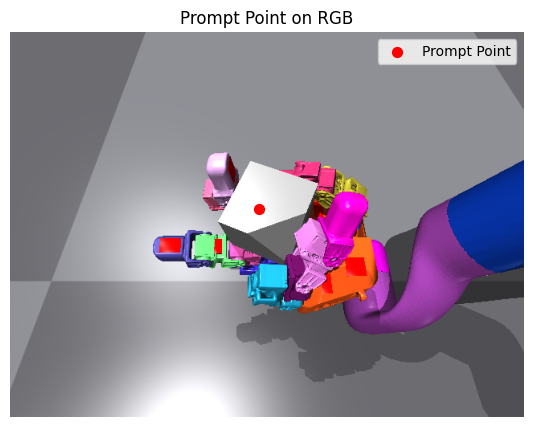

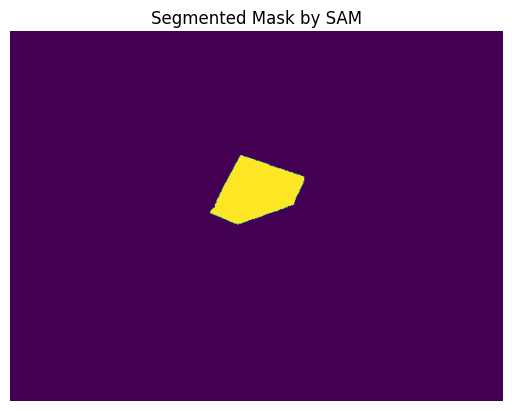

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1], c='red', s=50, label="Prompt Point")
plt.title("Prompt Point on RGB")
plt.axis("off")
plt.legend()
plt.show()

plt.figure()
plt.imshow(masks[0])  
plt.title("Segmented Mask by SAM")
plt.axis("off")
plt.show()

In [13]:
def get_prompt_neighborhood(center_uv, offsets=[(-35, 0), (35, 0), (0, -35), (0, 35),(-40, 0), (40, 0), (0, -40), (0, 40)]):
    u, v = center_uv
    points = [[u, v]] + [[u + dx, v + dy] for dx, dy in offsets]
    input_point = np.array(points)
    input_label = np.ones(len(points), dtype=int)
    return input_point, input_label

In [14]:
center_uv = (u, v)
input_point, input_label = get_prompt_neighborhood(center_uv)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

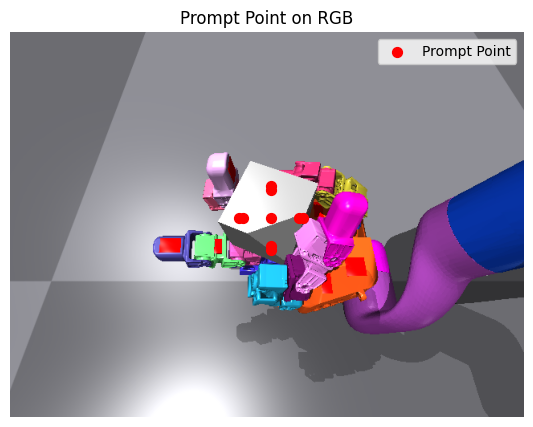

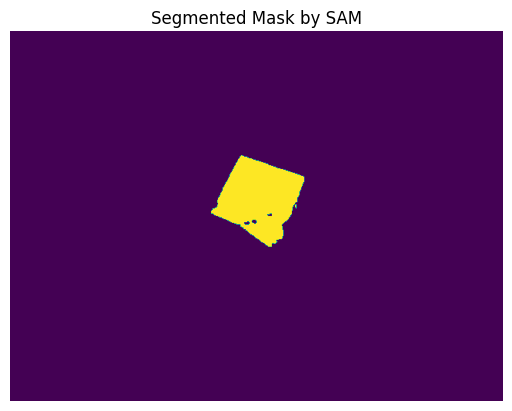

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1], c='red', s=50, label="Prompt Point")
plt.title("Prompt Point on RGB")
plt.axis("off")
plt.legend()
plt.show()

plt.figure()
plt.imshow(masks[0])  # 显示第一个分割结果
plt.title("Segmented Mask by SAM")
plt.axis("off")
plt.show()

In [16]:
mask = masks[0]  
depth_masked = np.where(mask, depth_img, 0.0)

In [17]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def depth_to_pointcloud_camera_coords(depth, fx, fy, cx, cy):
    H, W = depth.shape
    u, v = np.meshgrid(np.arange(W), np.arange(H)) 

    z = depth
    x = -(u - cx) * z / fx # flip x-axis 
    y = (v - cy) * z / fy

    points = np.stack((x, y, z), axis=-1) 
    return points.reshape(-1, 3)

def extract_intrinsics_from_proj_matrix(proj_matrix, width, height):
    fx = proj_matrix[0, 0] * width / 2
    fy = proj_matrix[1, 1] * height / 2
    cx = (1 - proj_matrix[0, 2]) * width / 2
    cy = (1 + proj_matrix[1, 2]) * height / 2
    return fx, fy, cx, cy

def inverse_view_matrix_to_cam_pose(view_matrix):
    view_inv = np.linalg.inv(view_matrix)
    R_world = view_inv[:3, :3]
    t_world = view_inv[:3, 3]
    return R_world, t_world


def transform_camera_to_world(points_cam, R_world, t_world):
    return (R_world @ points_cam.T).T + t_world


def depth_to_world_pointcloud(depth_tensor, proj_matrix, view_matrix, width, height):
    depth_np = depth_tensor.cpu().numpy()  
    fx, fy, cx, cy = extract_intrinsics_from_proj_matrix(proj_matrix, width, height)
    points_cam = depth_to_pointcloud_camera_coords(depth_np, fx, fy, cx, cy)
    R_world, t_world = inverse_view_matrix_to_cam_pose(view_matrix)
    points_world = transform_camera_to_world(points_cam, R_world, t_world)
    return points_cam, points_world

In [18]:
import torch

depth_tensor = torch.tensor(depth_masked)
height, width = depth_tensor.shape

points_cam, points_world = depth_to_world_pointcloud(depth_tensor, projection_matrix, view_matrix, width, height)

In [19]:
import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_cam)
o3d.visualization.draw_geometries([pcd])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_world)
o3d.visualization.draw_geometries([pcd])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [20]:
depth2 = depth_masked

物体中心在图像上的像素位置：u=337.0, v=231.6, z_cam=-0.242


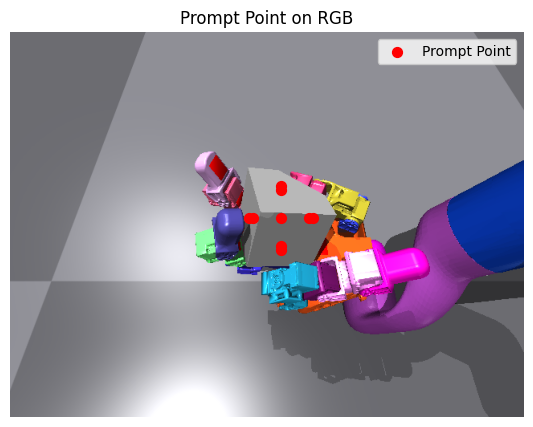

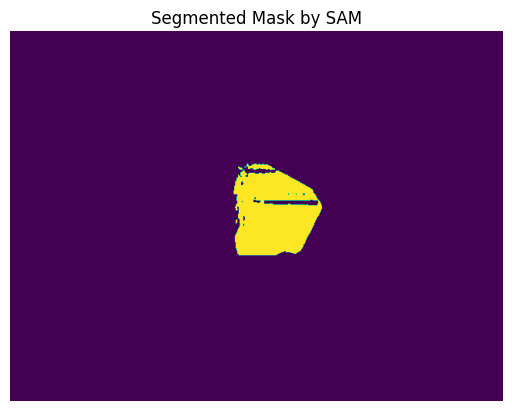

In [21]:
img_rgb_3 = np.load("./images/rgb3.npy")[:,:,:3]
predictor.set_image(img_rgb_3)

depth_img_3 = np.load("./images/depth3.npy")
depth_img_3 = torch.tensor(depth_img_3)

obj_pos_3 = np.load("./images/object_pose3.npy")[:,:3].reshape(-1)

height, width = depth_img_3.shape  
view_matrix = np.load("./view_matrix.npz.npy").reshape(4, 4).T
projection_matrix = np.load("proj_matrix.npz.npy").reshape(4, 4).T
u, v, z = world_to_pixel(obj_pos_3, view_matrix, projection_matrix, width, height)
print(f"物体中心在图像上的像素位置：u={u:.1f}, v={v:.1f}, z_cam={z:.3f}")

center_uv = (u, v)
input_point, input_label = get_prompt_neighborhood(center_uv)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb_3)
plt.scatter(input_point[:, 0], input_point[:, 1], c='red', s=50, label="Prompt Point")
plt.title("Prompt Point on RGB")
plt.axis("off")
plt.legend()
plt.show()

plt.figure()
plt.imshow(masks[0]) 
plt.title("Segmented Mask by SAM")
plt.axis("off")
plt.show()

mask = masks[0]  
depth_masked = np.where(mask, depth_img_3, 0.0)
depth3 = depth_masked

物体中心在图像上的像素位置：u=312.8, v=260.3, z_cam=-0.254


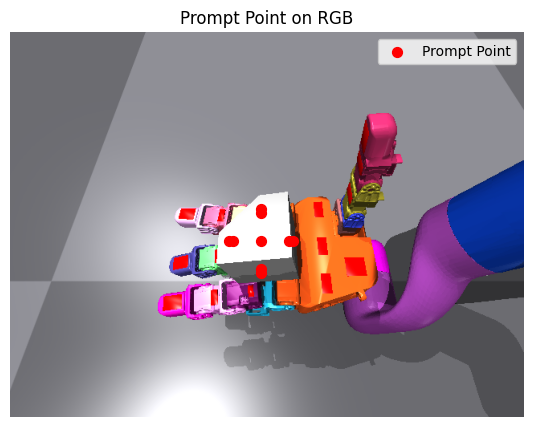

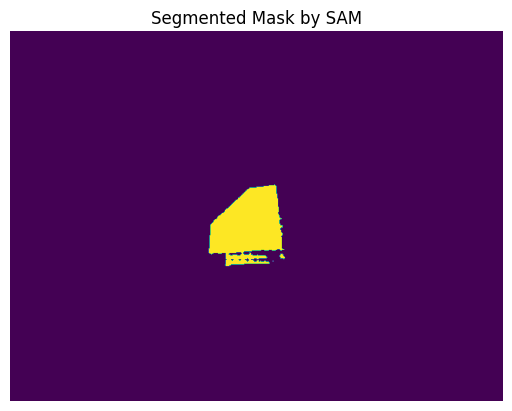

In [22]:
img_rgb = np.load("./images/rgb1.npy")[:,:,:3]
predictor.set_image(img_rgb)

depth_img = np.load("./images/depth1.npy")
depth_img = torch.tensor(depth_img)

obj_pos = np.load("./images/object_pose1.npy")[:,:3].reshape(-1)

height, width = depth_img.shape  
view_matrix = np.load("./view_matrix.npz.npy").reshape(4, 4).T
projection_matrix = np.load("proj_matrix.npz.npy").reshape(4, 4).T
u, v, z = world_to_pixel(obj_pos, view_matrix, projection_matrix, width, height)
print(f"物体中心在图像上的像素位置：u={u:.1f}, v={v:.1f}, z_cam={z:.3f}")

center_uv = (u, v)
input_point, input_label = get_prompt_neighborhood(center_uv)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1], c='red', s=50, label="Prompt Point")
plt.title("Prompt Point on RGB")
plt.axis("off")
plt.legend()
plt.show()

plt.figure()
plt.imshow(masks[0]) 
plt.title("Segmented Mask by SAM")
plt.axis("off")
plt.show()

mask = masks[0]  
depth_masked = np.where(mask, depth_img, 0.0)
depth1 = depth_masked

In [23]:
# plt.figure(figsize=(10, 5))
# plt.imshow(depth1)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.imshow(depth2)
# plt.show()

In [24]:
pose1 = np.load("./images/object_pose1.npy")
pose2 = np.load("./images/object_pose2.npy")

In [25]:
pose1, pose2

(array([[0.63569254, 0.01064401, 0.2031393 , 0.00962987, 0.09619209,
         0.01132492, 0.9952517 ]], dtype=float32),
 array([[ 0.62658715, -0.00602986,  0.22153695,  0.01744083,  0.04966621,
          0.9775732 ,  0.20391095]], dtype=float32))

In [26]:
depth_tensor = torch.tensor(depth1)
height, width = depth_tensor.shape

_, points_world_1 = depth_to_world_pointcloud(depth_tensor, projection_matrix, view_matrix, width, height)

depth_tensor = torch.tensor(depth2)
height, width = depth_tensor.shape

_, points_world_2 = depth_to_world_pointcloud(depth_tensor, projection_matrix, view_matrix, width, height)

depth_tensor = torch.tensor(depth3)
height, width = depth_tensor.shape

_, points_world_3 = depth_to_world_pointcloud(depth_tensor, projection_matrix, view_matrix, width, height)


In [27]:
mask1 = (depth1!=0)
mask2 = (depth2!=0)
mask3 = (depth3!=0)
points_world_1 = points_world_1[mask1.reshape(-1)]
points_world_2 = points_world_2[mask2.reshape(-1)]
points_world_3 = points_world_3[mask3.reshape(-1)]

In [28]:
import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_world_1)
# o3d.visualization.draw_geometries([pcd])
# points_world_1, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=4)
points_world_1_pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=int(points_world_1.shape[0] * 0.01), std_ratio=2.0)
o3d.visualization.draw_geometries([points_world_1_pcd])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_world_2)
# o3d.visualization.draw_geometries([pcd])
# points_world_2, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=4)
points_world_2_pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=int(points_world_2.shape[0] * 0.01), std_ratio=2.0)
o3d.visualization.draw_geometries([points_world_2_pcd])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_world_3)
# o3d.visualization.draw_geometries([pcd])
# points_world_2, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=4)
points_world_3_pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=int(points_world_3.shape[0] * 0.01), std_ratio=2.0)
o3d.visualization.draw_geometries([points_world_3_pcd])

In [29]:
def pose_to_matrix(pose):
    pos = pose[:3]
    quat = pose[3:]
    rot = R.from_quat(quat).as_matrix()
    T = np.eye(4)
    T[:3, :3] = rot
    T[:3, 3] = pos
    return T

In [30]:
T_wo1 = pose_to_matrix(pose1[0])
T_wo2 = pose_to_matrix(pose2[0])

In [31]:
points_world_1 = np.asarray(points_world_1_pcd.points) 
points_world_2 = np.asarray(points_world_2_pcd.points)  

T_obj1_world = np.linalg.inv(T_wo1)
T_obj2_world = np.linalg.inv(T_wo2)

points_obj0_1 = (T_obj1_world[:3, :3] @ points_world_1.T).T + T_obj1_world[:3, 3]
points_obj0_2 = (T_obj2_world[:3, :3] @ points_world_2.T).T + T_obj2_world[:3, 3]

In [32]:
points_combined = np.vstack([points_obj0_1, points_obj0_2])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_combined)
o3d.visualization.draw_geometries([pcd])

In [33]:
import open3d as o3d
import numpy as np
import copy
def draw_registration_result(source, target, transformation):
    """
    辅助函数，用于可视化配准结果
    :param source: 源点云
    :param target: 目标点云
    :param transformation: 变换矩阵
    """
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.paint_uniform_color([1, 0.706, 0])  # 源点云为橙色
    target_temp.paint_uniform_color([0, 0.651, 0.929]) # 目标点云为蓝色
    source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

In [280]:
def ICP_registration(source_pcd, target_pcd, threshold=0.02):
    print("\n2. 预处理与参数选择...")

    # 【重要】动态计算Voxel Size，使其更具适应性
    # 我们取点云包围盒对角线长度的一个比例作为voxel_size
    bbox = target_pcd.get_axis_aligned_bounding_box()
    diag_len = np.linalg.norm(bbox.get_max_bound() - bbox.get_min_bound())
    voxel_size = diag_len / 40.0  # 关键参数！可以尝试 /30, /40, /50 来调整

    print(f"点云包围盒对角线长度: {diag_len:.4f}")
    print(f"动态计算的 Voxel Size: {voxel_size:.4f}")

    source_down = source_pcd.voxel_down_sample(voxel_size)
    target_down = target_pcd.voxel_down_sample(voxel_size)
    print(f"降采样后, 源点云点数: {len(source_down.points)}, 目标点云点数: {len(target_down.points)}")

    # 估计法线
    radius_normal = voxel_size * 2
    source_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
    target_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

    # 计算FPFH特征
    radius_feature = voxel_size * 5
    source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        source_down, o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        target_down, o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    
    distance_threshold = voxel_size * 1

    ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source_down, target_down, source_fpfh, target_fpfh, True,
        distance_threshold,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        4, [ # 增加RANSAC迭代次数的健壮性
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
        ], o3d.pipelines.registration.RANSACConvergenceCriteria(5000000, 0.999)) # 增加最大迭代次数

    # 【关键诊断】打印RANSAC结果
    print("\n--- RANSAC 诊断信息 ---")
    print(ransac_result)
    print("------------------------")
    if ransac_result.fitness < 0.1:
        print("警告: RANSAC fitness 非常低，粗配准可能已失败！")
    else:
        print("RANSAC fitness 看起来不错，继续执行ICP。")

    print("显示粗配准结果...")
    #draw_registration_result(source_down, target_down, ransac_result.transformation)

    print("\n4. 执行Point-to-Plane ICP精配准...")
    init_transform = ransac_result.transformation
    icp_result = o3d.pipelines.registration.registration_icp(
        source_down, target_down, distance_threshold, init_transform,
        o3d.pipelines.registration.TransformationEstimationPointToPlane())

    # 【关键诊断】打印ICP结果
    print("\n--- ICP 诊断信息 ---")
    print(icp_result)
    print("--------------------")

    print("显示精配准结果...")
    #draw_registration_result(source_down, target_down, icp_result.transformation)

    print("\n5. 在原始高分辨率点云上执行最终精炼ICP...")

    # 为原始高密度点云定义一套独立的、更精细的参数
    radius_normal_final = voxel_size * 1.0  
    final_threshold = voxel_size * 0.5      

    # 【关键修正】在调用 PointToPlane ICP 之前，必须为原始点云估计法线！
    # 错误正是因为缺少了下面这两行代码。
    print(f":: 为原始点云估计法线 (使用精细半径: {radius_normal_final:.4f})...")
    source_pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal_final, max_nn=30))
    target_pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal_final, max_nn=30))

    # 使用上一步的结果作为极其优秀的初始值
    init_transform_final = icp_result.transformation

    # 现在可以安全地调用 PointToPlane ICP 了
    final_icp_result = o3d.pipelines.registration.registration_icp(
        source_pcd, target_pcd, final_threshold, init_transform_final,
        o3d.pipelines.registration.TransformationEstimationPointToPlane())


    print("最终精炼ICP完成。最终变换矩阵：")
    print(final_icp_result.transformation)

    print("\n--- 最终ICP诊断信息 ---")
    print(final_icp_result)

    print("显示最终精炼配准结果 (这应该是你想要的效果)...")
    #draw_registration_result(source_pcd, target_pcd, final_icp_result.transformation)
    return source_pcd.transform(final_icp_result.transformation)+target_pcd

In [ ]:
source_pcd = copy.deepcopy(points_world_1_pcd)
target_pcd = copy.deepcopy(points_world_3_pcd)
draw_registration_result(source_pcd, target_pcd, np.identity(4))

In [282]:
pcd_combined = ICP_registration(source_pcd, target_pcd, threshold=0.02)
#pcd_combined = pcd_combined.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)[0]
o3d.visualization.draw_geometries([pcd_combined])


2. 预处理与参数选择...
点云包围盒对角线长度: 0.1304
动态计算的 Voxel Size: 0.0033
降采样后, 源点云点数: 538, 目标点云点数: 1008

--- RANSAC 诊断信息 ---
RegistrationResult with fitness=7.843866e-01, inlier_rmse=1.604851e-03, and correspondence_set size of 422
Access transformation to get result.
------------------------
RANSAC fitness 看起来不错，继续执行ICP。
显示粗配准结果...

4. 执行Point-to-Plane ICP精配准...

--- ICP 诊断信息 ---
RegistrationResult with fitness=8.104089e-01, inlier_rmse=1.377774e-03, and correspondence_set size of 436
Access transformation to get result.
--------------------
显示精配准结果...

5. 在原始高分辨率点云上执行最终精炼ICP...
:: 为原始点云估计法线 (使用精细半径: 0.0033)...
最终精炼ICP完成。最终变换矩阵：
[[ 0.12865933  0.9663341  -0.22281201  0.57078223]
 [-0.97814271  0.08664812 -0.189021    0.65611162]
 [-0.1633512   0.24226126  0.95636074  0.13154866]
 [ 0.          0.          0.          1.        ]]

--- 最终ICP诊断信息 ---
RegistrationResult with fitness=8.345502e-01, inlier_rmse=5.340590e-04, and correspondence_set size of 5715
Access transformation to get result.
显示最终精炼

In [ ]:
source_pcd = copy.deepcopy(points_world_2_pcd)
#o3d.visualization.draw_geometries([source_pcd])
pcd_combined_1 = ICP_registration(source_pcd, pcd_combined, threshold=0.02)
#pcd_combined = pcd_combined.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)[0]
o3d.visualization.draw_geometries([pcd_combined_1])


2. 预处理与参数选择...
点云包围盒对角线长度: 0.1347
动态计算的 Voxel Size: 0.0034
降采样后, 源点云点数: 535, 目标点云点数: 1114

--- RANSAC 诊断信息 ---
RegistrationResult with fitness=7.252336e-01, inlier_rmse=2.012021e-03, and correspondence_set size of 388
Access transformation to get result.
------------------------
RANSAC fitness 看起来不错，继续执行ICP。
显示粗配准结果...

4. 执行Point-to-Plane ICP精配准...

--- ICP 诊断信息 ---
RegistrationResult with fitness=7.813084e-01, inlier_rmse=1.538797e-03, and correspondence_set size of 418
Access transformation to get result.
--------------------
显示精配准结果...

5. 在原始高分辨率点云上执行最终精炼ICP...
:: 为原始点云估计法线 (使用精细半径: 0.0034)...
最终精炼ICP完成。最终变换矩阵：
[[ 0.60838749  0.72990565 -0.31161258  0.31169346]
 [-0.78380407  0.49097061 -0.3802618   0.57688085]
 [-0.12456262  0.47558973  0.8708034   0.11381733]
 [ 0.          0.          0.          1.        ]]

--- 最终ICP诊断信息 ---
RegistrationResult with fitness=7.519990e-01, inlier_rmse=4.513855e-04, and correspondence_set size of 6301
Access transformation to get result.
显示最终精炼

: 